<a href="https://colab.research.google.com/github/ekuelkpodar/Complex-Systems-Google-Colab-Experiment/blob/main/Decentralized_swarm_consensus_under_Byzantine_fault_injection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Decentralized Swarm Consensus under Byzantine Faults
This simulation explores how a swarm of drones reaches consensus (using a Gossip-like protocol) on a dynamic graph when a fraction of nodes are malicious (Byzantine).

In [2]:
!pip install mesa networkx matplotlib

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 275.1/275.1 kB 7.2 MB/s eta 0:00:00


In [5]:
import random
import networkx as nx
import matplotlib.pyplot as plt
from mesa import Agent, Model
from mesa.space import NetworkGrid
from mesa.datacollection import DataCollector

def get_consensus_error(model):
    """Calculate the spread of values among non-Byzantine agents."""
    values = [a.value for a in model.agents if not a.is_byzantine]
    if not values: return 0
    return max(values) - min(values)

class DroneAgent(Agent):
    def __init__(self, model, is_byzantine=False):
        super().__init__(model)
        self.is_byzantine = is_byzantine
        self.value = random.uniform(0, 100) if not is_byzantine else -1

    def step(self):
        # Access neighbors directly through the NetworkX graph G
        # In NetworkGrid, self.pos is the node ID
        neighbor_nodes = list(self.model.G.neighbors(self.pos))

        neighbor_agents = []
        for node in neighbor_nodes:
            # Fetch agents residing on that node
            agents_at_node = self.model.grid.get_cell_list_contents([node])
            neighbor_agents.extend(agents_at_node)

        if not self.is_byzantine:
            neighbor_values = [n.value for n in neighbor_agents if n.value != -1]
            if neighbor_values:
                # Update value based on neighborhood average
                self.value = (self.value + sum(neighbor_values)) / (1 + len(neighbor_values))
        else:
            # Byzantine disruption
            self.value = random.choice([0, 100, -50, 200])

class SwarmModel(Model):
    def __init__(self, num_nodes, byzantine_fraction, prob_edge=0.15):
        super().__init__()
        self.G = nx.erdos_renyi_graph(n=num_nodes, p=prob_edge)
        self.grid = NetworkGrid(self.G)

        for i, node in enumerate(self.G.nodes()):
            is_byz = random.random() < byzantine_fraction
            a = DroneAgent(self, is_byzantine=is_byz)
            self.grid.place_agent(a, node)

        self.datacollector = DataCollector(
            model_reporters={"ConsensusError": get_consensus_error}
        )

    def step(self):
        self.datacollector.collect(self)
        self.agents.shuffle_do("step")

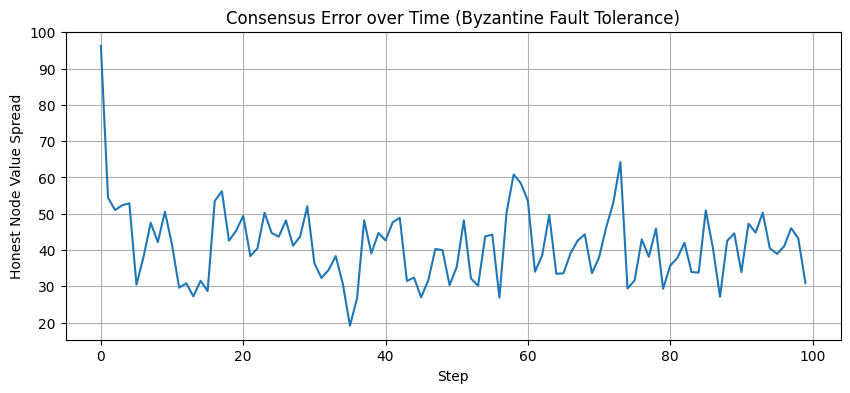

In [6]:
# Re-instantiate and run
model = SwarmModel(num_nodes=50, byzantine_fraction=0.1, prob_edge=0.15)

for i in range(100):
    model.step()

results = model.datacollector.get_model_vars_dataframe()
plt.figure(figsize=(10, 4))
plt.plot(results["ConsensusError"])
plt.title("Consensus Error over Time (Byzantine Fault Tolerance)")
plt.xlabel("Step")
plt.ylabel("Honest Node Value Spread")
plt.grid(True)
plt.show()

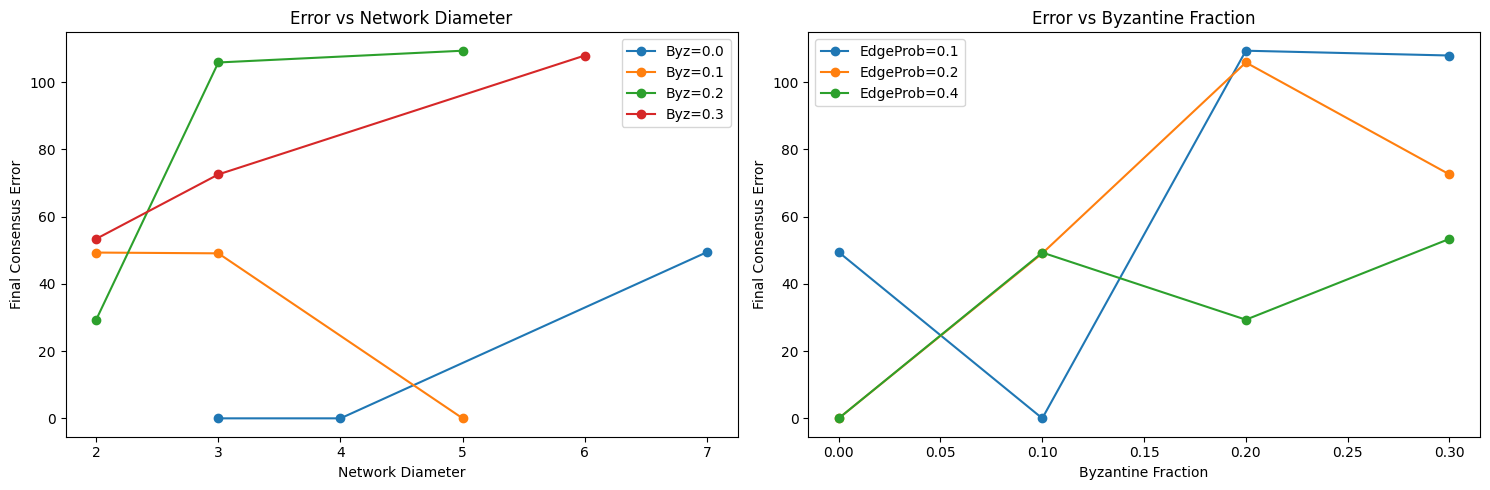

In [8]:
import numpy as np
import pandas as pd

def run_experiment(num_nodes=40, byz_fractions=[0.0, 0.1, 0.2, 0.3], edge_probs=[0.1, 0.2, 0.4]):
    results_list = []
    for bf in byz_fractions:
        for ep in edge_probs:
            model = SwarmModel(num_nodes=num_nodes, byzantine_fraction=bf, prob_edge=ep)
            # Calculate diameter (approximate for diameter of largest component)
            try:
                if nx.is_connected(model.G):
                    diameter = nx.diameter(model.G)
                else:
                    largest_cc = max(nx.connected_components(model.G), key=len)
                    diameter = nx.diameter(model.G.subgraph(largest_cc))
            except:
                diameter = num_nodes

            for _ in range(100):
                model.step()

            df = model.datacollector.get_model_vars_dataframe()
            final_error = df["ConsensusError"].iloc[-1]
            results_list.append({"ByzantineFraction": bf, "EdgeProb": ep, "Diameter": diameter, "FinalError": final_error})
    return pd.DataFrame(results_list)

# Run the sweep
sweep_results = run_experiment()

# Visualize the impact
fig, ax = plt.subplots(1, 2, figsize=(15, 5))
for bf in sweep_results["ByzantineFraction"].unique():
    subset = sweep_results[sweep_results["ByzantineFraction"] == bf]
    ax[0].plot(subset["Diameter"], subset["FinalError"], "o-", label=f"Byz={bf}")

ax[0].set_title("Error vs Network Diameter")
ax[0].set_xlabel("Network Diameter")
ax[0].set_ylabel("Final Consensus Error")
ax[0].legend()

for ep in sweep_results["EdgeProb"].unique():
    subset = sweep_results[sweep_results["EdgeProb"] == ep]
    ax[1].plot(subset["ByzantineFraction"], subset["FinalError"], "o-", label=f"EdgeProb={ep}")

ax[1].set_title("Error vs Byzantine Fraction")
ax[1].set_xlabel("Byzantine Fraction")
ax[1].set_ylabel("Final Consensus Error")
ax[1].legend()
plt.tight_layout()
plt.show()

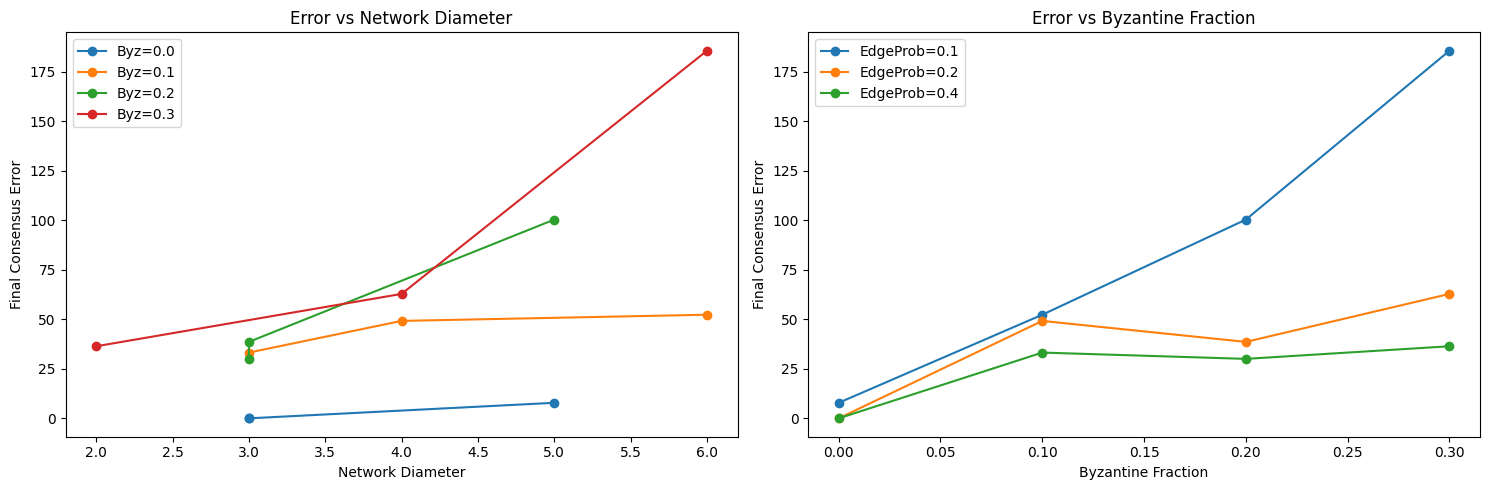

In [7]:
import numpy as np
import pandas as pd

def run_experiment(num_nodes=40, byz_fractions=[0.0, 0.1, 0.2, 0.3], edge_probs=[0.1, 0.2, 0.4]):
    results_list = []
    for bf in byz_fractions:
        for ep in edge_probs:
            model = SwarmModel(num_nodes=num_nodes, byzantine_fraction=bf, prob_edge=ep)
            # Calculate diameter (approximate for diameter of largest component if disconnected)
            try:
                diameter = nx.diameter(model.G) if nx.is_connected(model.G) else nx.diameter(model.G.subgraph(max(nx.connected_components(model.G), key=len)))
            except:
                diameter = num_nodes # Fallback

            for _ in range(100):
                model.step()

            df = model.datacollector.get_model_vars_dataframe()
            final_error = df["ConsensusError"].iloc[-1]
            results_list.append({"ByzantineFraction": bf, "EdgeProb": ep, "Diameter": diameter, "FinalError": final_error})
    return pd.DataFrame(results_list)

# Run the sweep
sweep_results = run_experiment()

# Visualize the impact
fig, ax = plt.subplots(1, 2, figsize=(15, 5))
for bf in sweep_results["ByzantineFraction"].unique():
    subset = sweep_results[sweep_results["ByzantineFraction"] == bf]
    ax[0].plot(subset["Diameter"], subset["FinalError"], 'o-', label=f'Byz={bf}')

ax[0].set_title("Error vs Network Diameter")
ax[0].set_xlabel("Network Diameter")
ax[0].set_ylabel("Final Consensus Error")
ax[0].legend()

for ep in sweep_results["EdgeProb"].unique():
    subset = sweep_results[sweep_results["EdgeProb"] == ep]
    ax[1].plot(subset["ByzantineFraction"], subset["FinalError"], 'o-', label=f'EdgeProb={ep}')

ax[1].set_title("Error vs Byzantine Fraction")
ax[1].set_xlabel("Byzantine Fraction")
ax[1].set_ylabel("Final Consensus Error")
ax[1].legend()
plt.tight_layout()
plt.show()